In [4]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('/content/Telco-Customer-Churn.csv')

# Display the first 5 rows of the DataFrame to inspect the data
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Display a concise summary of the DataFrame, including data types and non-null values
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

In [6]:
# Check for missing values in each column
display(df.isnull().sum())

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [7]:
# Convert 'TotalCharges' to numeric, coercing errors to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check for newly introduced missing values in 'TotalCharges'
missing_total_charges = df['TotalCharges'].isnull().sum()
print(f"Number of missing 'TotalCharges' values after conversion: {missing_total_charges}")

# Display rows with missing TotalCharges to understand their characteristics
if missing_total_charges > 0:
    print("\nRows with missing 'TotalCharges':")
    display(df[df['TotalCharges'].isnull()])


Number of missing 'TotalCharges' values after conversion: 11

Rows with missing 'TotalCharges':


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [12]:
# Fill NaN values in 'TotalCharges' with 0
df['TotalCharges'] = df['TotalCharges'].fillna(0)

# Verify that there are no more missing values in 'TotalCharges'
print(f"Number of missing 'TotalCharges' values after filling: {df['TotalCharges'].isnull().sum()}")

Number of missing 'TotalCharges' values after filling: 0


In [13]:
# Re-check for missing values in each column after cleaning 'TotalCharges'
display(df.isnull().sum())

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


In [14]:
# Display the entire DataFrame
display(df)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [16]:
# Re-index the DataFrame to start from 1
df.index = df.index + 1

# Display the DataFrame with the new index
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
2,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
3,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
4,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
5,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
6,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [18]:
# Reset the index to default (0-based) first, dropping the old index
df = df.reset_index(drop=True)

# Now, add 1 to make the index 1-based
df.index = df.index + 1

# Display the DataFrame head to confirm the new 1-based index
display(df.head())

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
2,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
3,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
4,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
5,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [19]:
display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


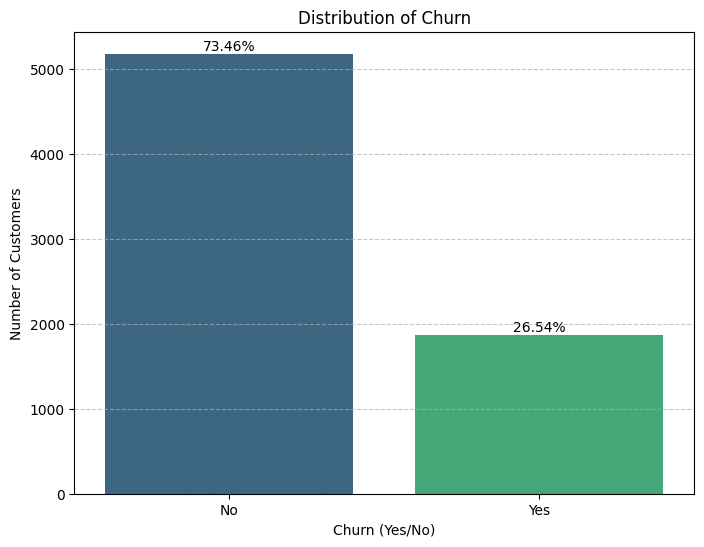

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate churn rate
churn_counts = df['Churn'].value_counts()
churn_percentage = df['Churn'].value_counts(normalize=True) * 100

# Create a DataFrame for plotting
churn_df = pd.DataFrame({
    'Churn': churn_counts.index,
    'Count': churn_counts.values,
    'Percentage': churn_percentage.values
})

# Create the bar plot
plt.figure(figsize=(8, 6))
sns.barplot(x='Churn', y='Count', data=churn_df, hue='Churn', palette='viridis', legend=False)

# Add percentage labels on top of the bars
for index, row in churn_df.iterrows():
    plt.text(index, row['Count'], f"{row['Percentage']:.2f}%", color='black', ha="center", va='bottom')

plt.title('Distribution of Churn')
plt.xlabel('Churn (Yes/No)')
plt.ylabel('Number of Customers')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This bar plot shows the distribution of customers who churned ('Yes') and those who did not ('No'), along with their respective percentages. This helps in understanding the baseline churn rate in the dataset.

As you can see, there are a few rows where `TotalCharges` was not a valid number (likely empty strings or spaces) and has now been converted to `NaN`. These customers typically have a `tenure` of 0, meaning they are new customers and haven't accumulated any total charges yet. Depending on the analysis, these rows might need to be dropped or imputed.

## Exploratory Data Analysis (EDA) - Categorical Features

Let's analyze the categorical features to understand their distributions and how they impact customer churn. We'll start with `gender`, `Partner`, and `Dependents`.

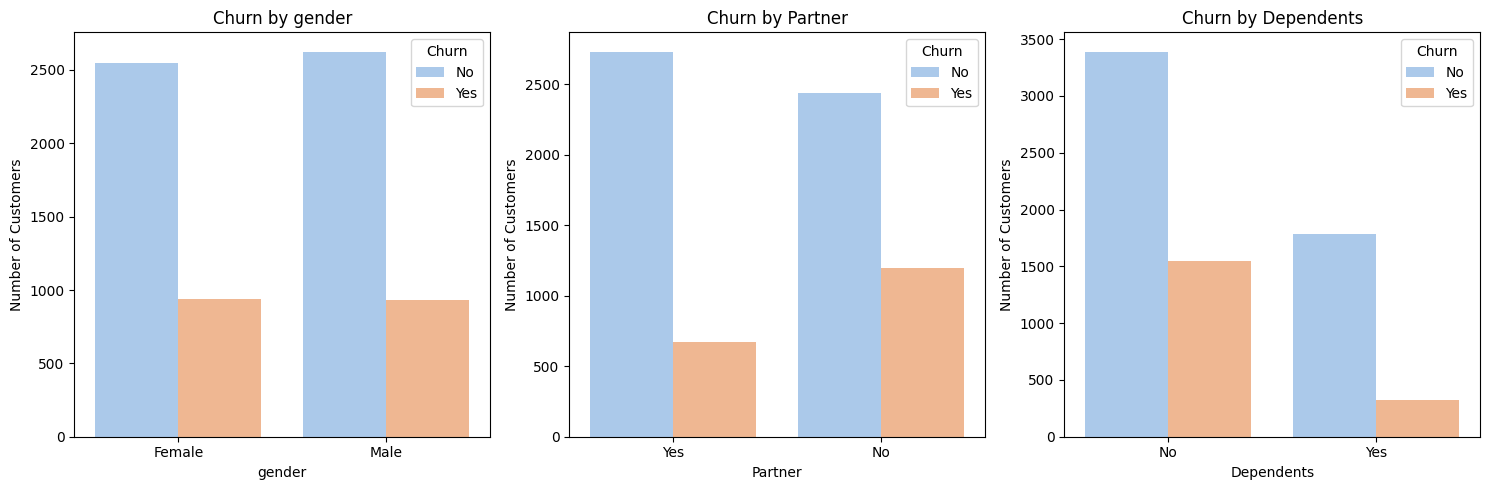

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features = ['gender', 'Partner', 'Dependents']

plt.figure(figsize=(15, 5))

for i, feature in enumerate(categorical_features):
    plt.subplot(1, len(categorical_features), i + 1)
    sns.countplot(x=feature, hue='Churn', data=df, palette='pastel')
    plt.title(f'Churn by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
    plt.legend(title='Churn')

plt.tight_layout()
plt.show()

From these plots, we can observe:

*   **Gender**: It appears that gender does not have a significant impact on churn, as the distribution of churned vs. non-churned customers is quite similar for both males and females.
*   **Partner**: Customers with partners (`Yes`) seem to have a lower churn rate compared to those without partners (`No`). This suggests that having a partner might indicate more stability or commitment to the service.
*   **Dependents**: Similarly, customers with dependents (`Yes`) show a lower churn rate than those without dependents (`No`), reinforcing the idea that family responsibilities might lead to lower churn.

## Exploring More Categorical Features: `PhoneService`, `MultipleLines`, `InternetService`

Let's analyze how services like phone, multiple lines, and internet service are related to customer churn.

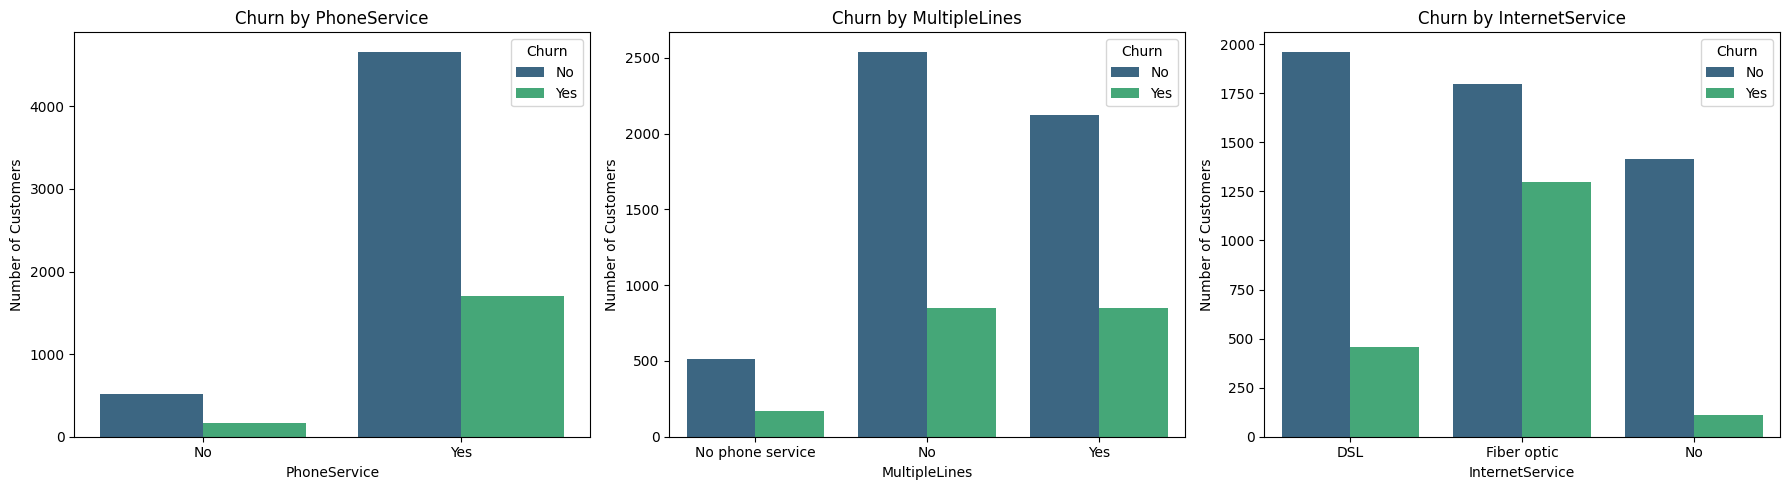

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_2 = ['PhoneService', 'MultipleLines', 'InternetService']

plt.figure(figsize=(18, 5))

for i, feature in enumerate(categorical_features_2):
    plt.subplot(1, len(categorical_features_2), i + 1)
    sns.countplot(x=feature, hue='Churn', data=df, palette='viridis')
    plt.title(f'Churn by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
    plt.legend(title='Churn')

plt.tight_layout()
plt.show()

From these plots, we can observe:

*   **PhoneService**: Most customers have phone service, and there doesn't seem to be a strong difference in churn rate between those with and without phone service.
*   **MultipleLines**: Customers with multiple lines (`Yes`) might have a slightly higher churn rate compared to those with no multiple lines (`No`) or no phone service.
*   **InternetService**: There's a notable difference in churn rates based on internet service type. Customers with `Fiber optic` internet service appear to have a significantly higher churn rate compared to those with `DSL` or no internet service.

## Exploring More Categorical Features: `OnlineSecurity`, `OnlineBackup`, `DeviceProtection`, `TechSupport`, `StreamingTV`, `StreamingMovies`

Let's continue our exploration by analyzing how additional services and features are related to customer churn.

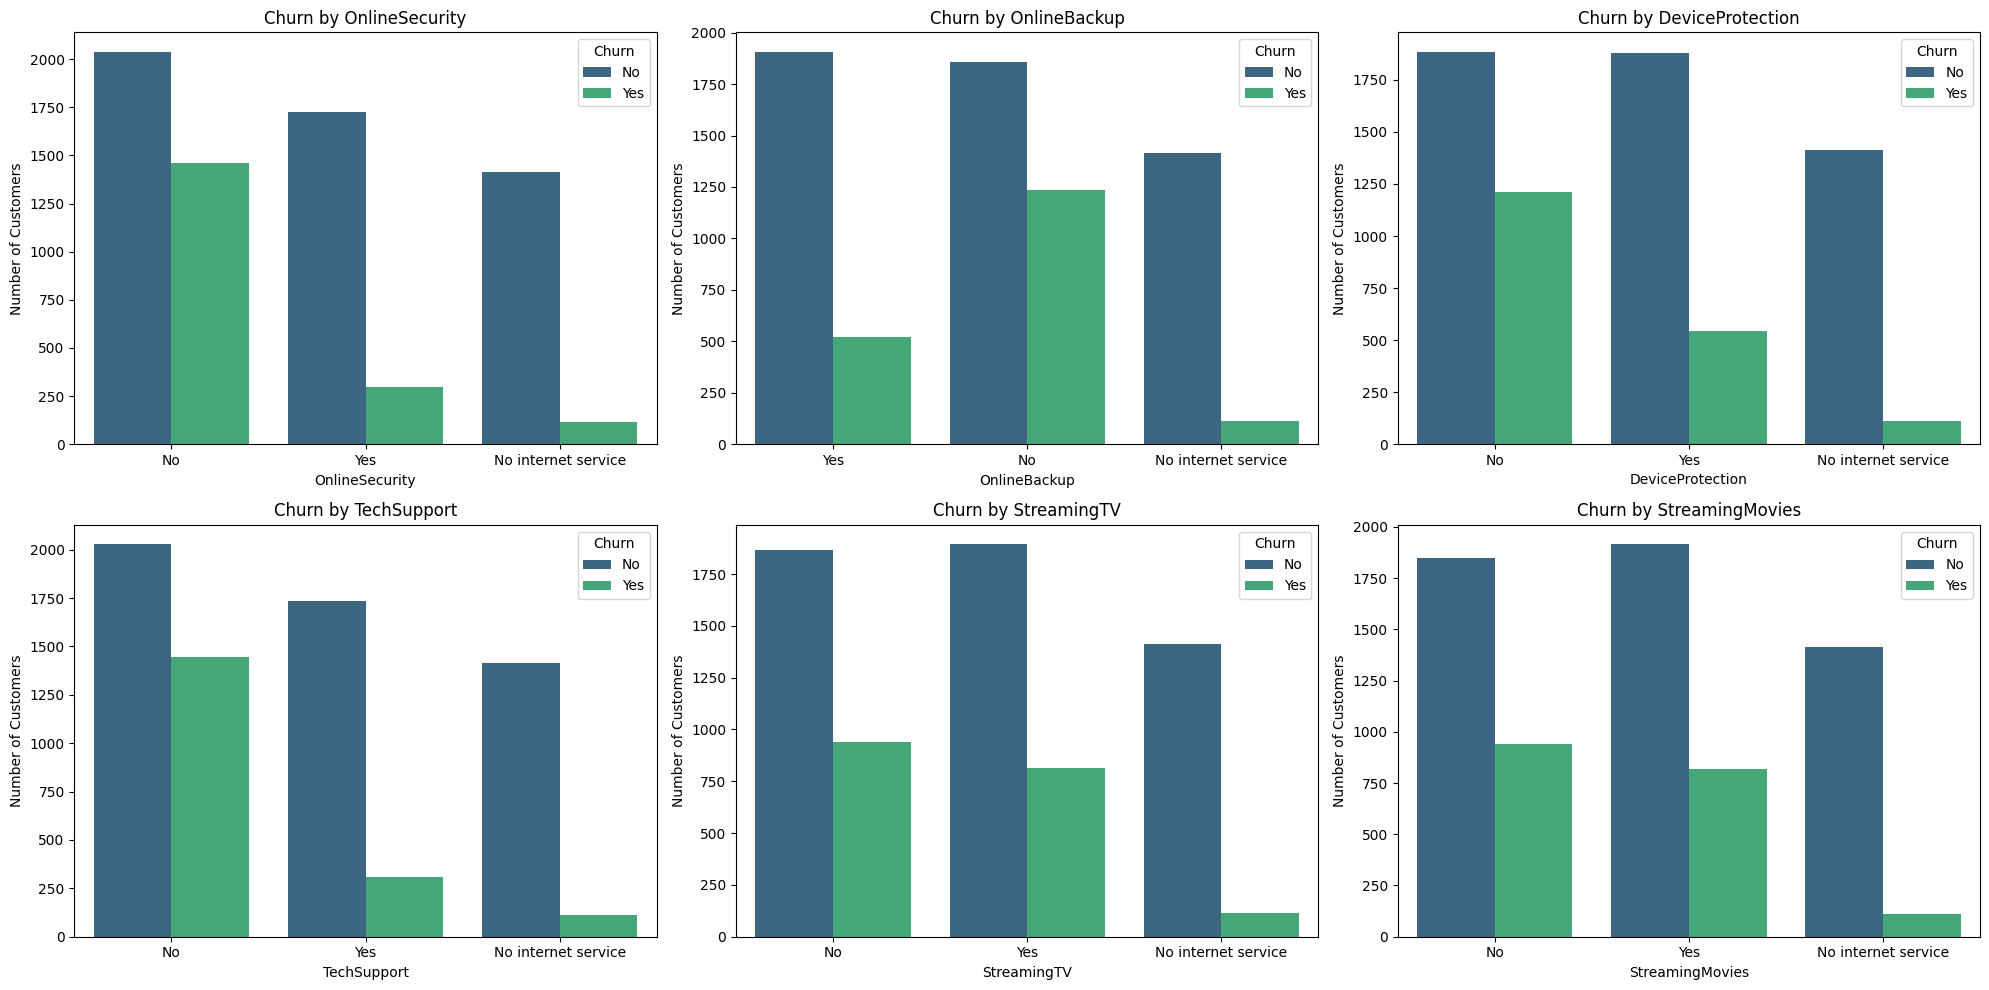

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_3 = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

plt.figure(figsize=(20, 10)) # Adjust figure size for better readability

for i, feature in enumerate(categorical_features_3):
    plt.subplot(2, 3, i + 1) # Arrange plots in 2 rows, 3 columns
    sns.countplot(x=feature, hue='Churn', data=df, palette='viridis')
    plt.title(f'Churn by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
    plt.legend(title='Churn')

plt.tight_layout()
plt.show()

Let's summarize the observations from these plots.

## Exploring Remaining Categorical Features: `Contract`, `PaperlessBilling`, `PaymentMethod`

Let's analyze the last set of categorical features to see their impact on customer churn.

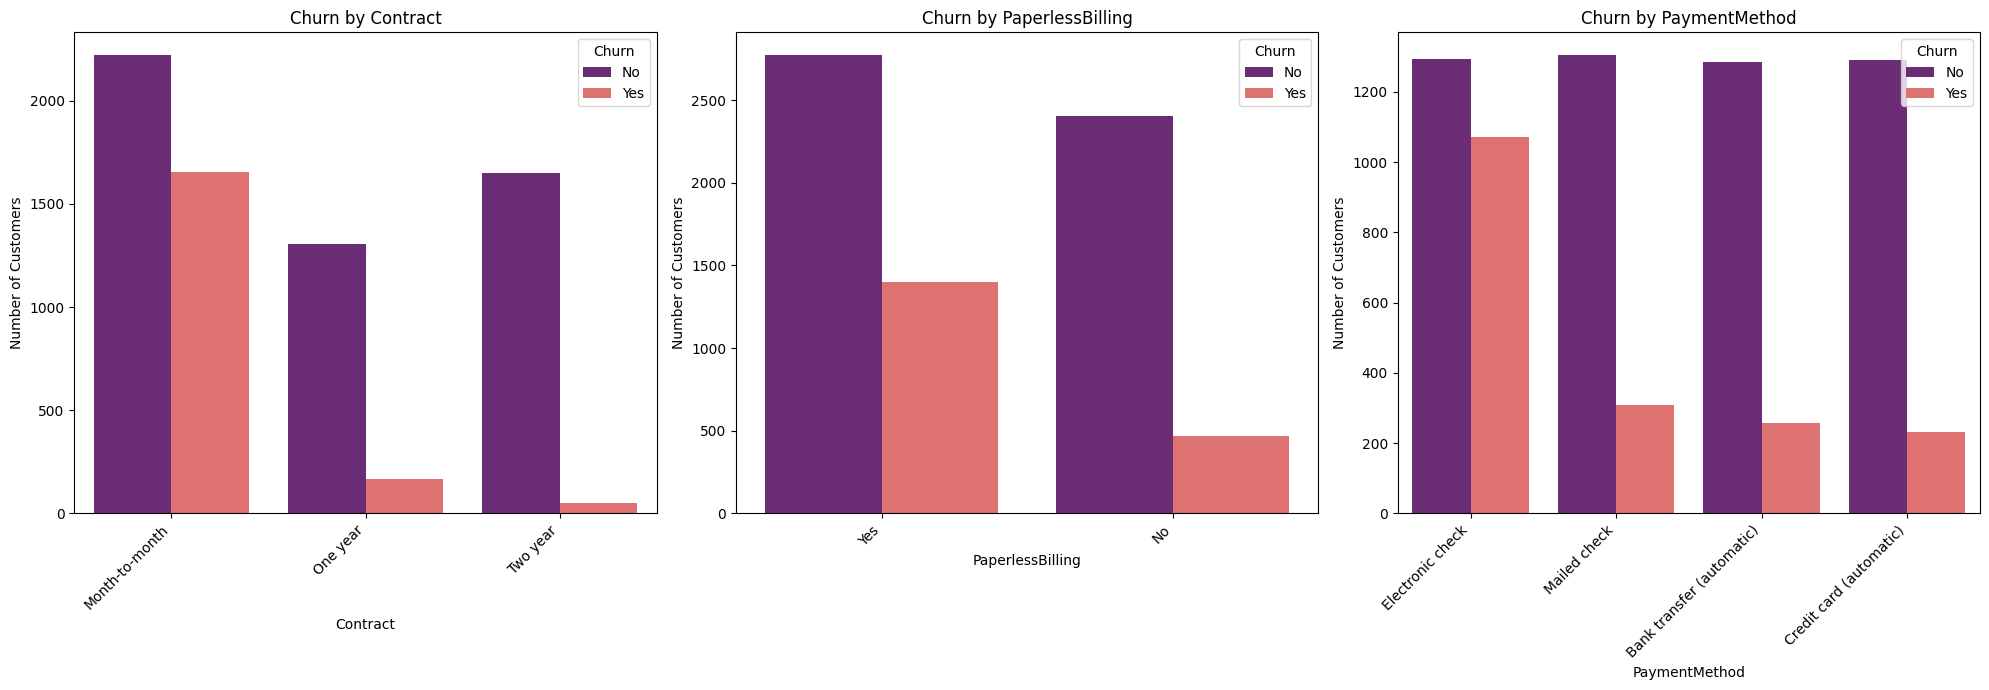

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

categorical_features_4 = ['Contract', 'PaperlessBilling', 'PaymentMethod']

plt.figure(figsize=(20, 7))

for i, feature in enumerate(categorical_features_4):
    plt.subplot(1, 3, i + 1) # Arrange plots in 1 row, 3 columns
    sns.countplot(x=feature, hue='Churn', data=df, palette='magma')
    plt.title(f'Churn by {feature}')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')
    plt.legend(title='Churn')
    plt.xticks(rotation=45, ha='right') # Rotate labels for better readability

plt.tight_layout()
plt.show()

Let's summarize the observations from these final categorical feature plots.

## Exploratory Data Analysis (EDA) - Numerical Features

Let's now analyze the numerical features (`tenure`, `MonthlyCharges`, `TotalCharges`) to understand their distribution and relationship with customer churn.

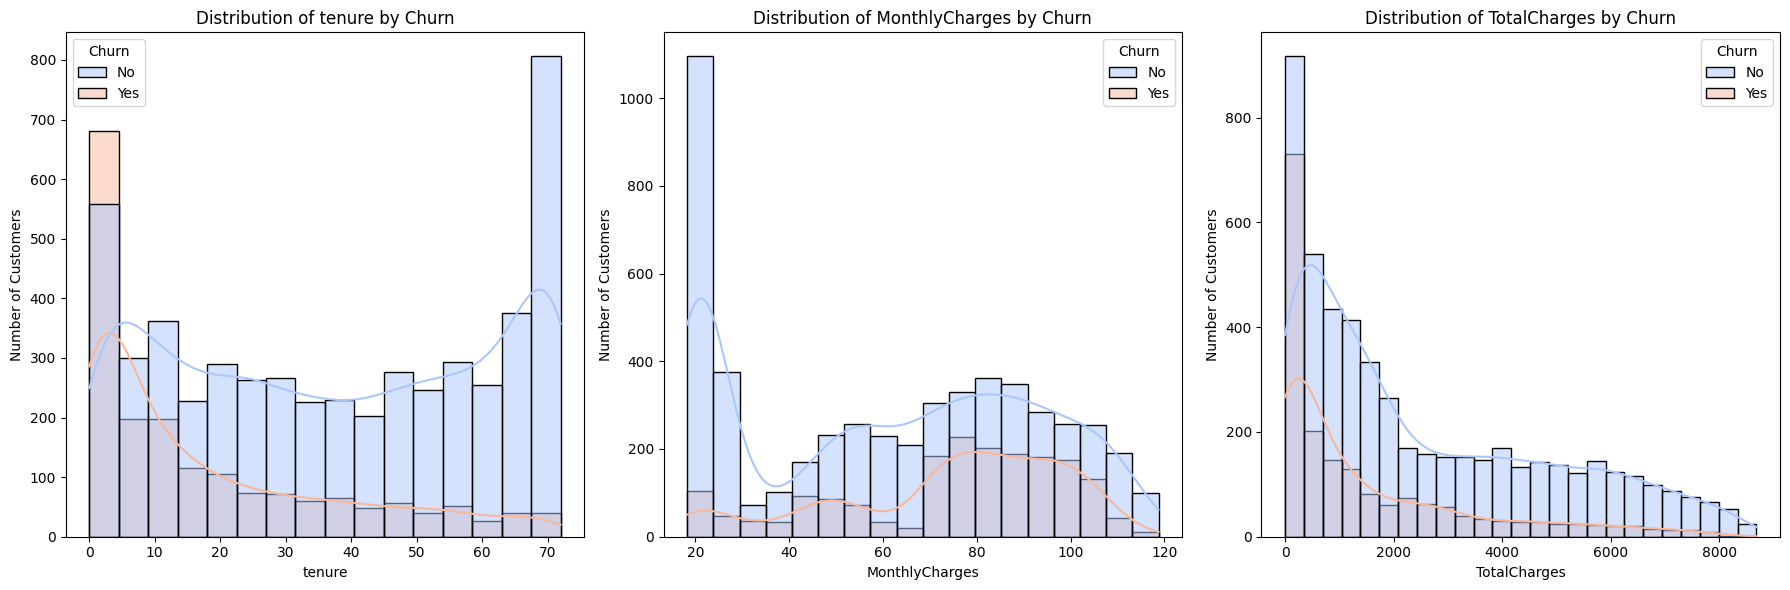

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']

plt.figure(figsize=(18, 6))

for i, feature in enumerate(numerical_features):
    plt.subplot(1, 3, i + 1) # Arrange plots in 1 row, 3 columns
    sns.histplot(data=df, x=feature, hue='Churn', kde=True, palette='coolwarm')
    plt.title(f'Distribution of {feature} by Churn')
    plt.xlabel(feature)
    plt.ylabel('Number of Customers')

plt.tight_layout()
plt.show()

Let's summarize the observations from the numerical feature plots.

## Data Preparation for Power BI

To prepare the data for Power BI, we will perform the following preprocessing steps:
1.  Drop the `customerID` column.
2.  Convert the `Churn` column to numerical (0 and 1).
3.  Apply One-Hot Encoding to all other categorical features.

In [27]:
# Drop the 'customerID' column as it's not needed for modeling or aggregated analysis
df_processed = df.drop('customerID', axis=1)

# Convert 'Churn' column to numerical: 'Yes' -> 1, 'No' -> 0
df_processed['Churn'] = df_processed['Churn'].map({'Yes': 1, 'No': 0})

display(df_processed.head())

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
1,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
2,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
3,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
4,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
5,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [28]:
# Identify categorical columns for one-hot encoding
categorical_cols = df_processed.select_dtypes(include='object').columns

# Apply one-hot encoding
df_encoded = pd.get_dummies(df_processed, columns=categorical_cols, drop_first=True)

display(df_encoded.head())
print(f"Original DataFrame shape: {df.shape}")
print(f"Processed DataFrame shape: {df_encoded.shape}")

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,...,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
1,0,1,29.85,29.85,0,False,True,False,False,True,...,False,False,False,False,False,False,True,False,True,False
2,0,34,56.95,1889.50,0,True,False,False,True,False,...,False,False,False,False,True,False,False,False,False,True
3,0,2,53.85,108.15,1,True,False,False,True,False,...,False,False,False,False,False,False,True,False,False,True
4,0,45,42.30,1840.75,0,True,False,False,False,True,...,False,False,False,False,True,False,False,False,False,False
5,0,2,70.70,151.65,1,False,False,False,True,False,...,False,False,False,False,False,False,True,False,True,False


Original DataFrame shape: (7043, 21)
Processed DataFrame shape: (7043, 31)


The data is now preprocessed and ready for export to Power BI. You can save `df_encoded` to a CSV file or another format that Power BI can easily import.

In [30]:
# Save the processed DataFrame to a CSV file
output_path = '/content/telco_customer_churn_processed.csv'
df_encoded.to_csv(output_path, index=False)

print(f"Processed data saved to: {output_path}")

Processed data saved to: /content/telco_customer_churn_processed.csv


In [29]:
# Save the processed DataFrame to a CSV file
output_path = '/content/telco_customer_churn_processed.csv'
df_encoded.to_csv(output_path, index=False)

print(f"Processed data saved to: {output_path}")

Processed data saved to: /content/telco_customer_churn_processed.csv


In [ ]:
from google.colab import files

files.download(output_path)

آپ کی پروسیس شدہ ڈیٹا فائل (`telco_customer_churn_processed.csv`) اب تیار ہے اور آپ کی Colab انوائرنمنٹ میں محفوظ کر دی گئی ہے۔ آپ اسے ڈاؤن لوڈ کر کے پاور بی آئی میں استعمال کر سکتے ہیں۔

آپ اس فائل کو اپنی Colab انوائرنمنٹ کے فائل براؤزر (left sidebar) سے ڈاؤن لوڈ کر سکتے ہیں، یا مزید سہولت کے لیے میں آپ کو ایک کوڈ بلاک بھی فراہم کر سکتا ہوں جو اسے براہ راست ڈاؤن لوڈ کرنے کا آپشن دے گا۔

اگر آپ چاہیں تو میں مزید کوئی ڈیٹا ایکسپلوریشن یا تجزیہ کر سکتا ہوں، یا اب آپ اسے پاور بی آئی میں استعمال کرنے کے لیے تیار ہیں۔

Your processed data file (`telco_customer_churn_processed.csv`) is now ready and has been saved in your Colab environment. You can download it and use it in Power BI.

You can download this file from the file browser in your Colab environment (left sidebar), or I can provide you with a code block that gives you the option to download it directly for more convenience.

If you'd like, I can perform any further data exploration or analysis, or you are now ready to use it in Power BI.